# BioPlex Compartment Organization Project — Stage 2

**Goal of this notebook:** for each cell line (HEK293T, HCT116), build the compartment x
compartment "mixing matrix" -- how often pairs of compartments interact vs. how often a
degree-matched random network would predict -- and turn that into per-pair significance plus a
single global summary statistic (mutual information).

**Inputs** (from Stages 0-1, saved in `data/stage0_1` and loaded fresh so this notebook is self-contained):
- `bioplex_hek293t_edges.csv`, `bioplex_hct116_edges.csv`
- `protein_compartments.csv`

**Outputs** (saved to `./data/stage2`):
- `mixing_matrix_{cell_line}.csv` — raw observed compartment x compartment edge counts
- `mixing_zscores_{cell_line}.csv` — per-pair z-scores + FDR-corrected significance
- `mixing_summary_{cell_line}.json` — total edges used, mutual information (bits)

**As with the earlier notebook, I couldn't run this end-to-end myself** (no network access in my
environment) -- the double-edge-swap null model in particular is worth watching closely on first
run, since it's the one piece here doing real statistical work rather than bookkeeping.

## 2.0 Setup and load Stage 0/1 outputs

In [45]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations_with_replacement

INPUT_DIR = Path("data/stage0_1")   # Stage 0/1 outputs (edge lists, protein_compartments.csv)
OUTPUT_DIR = Path("data/stage2")    # this notebook's own outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

pd.set_option("display.max_columns", 20)

In [46]:
def load_graph(edge_csv: str) -> nx.Graph:
    """Load an undirected graph from a Stage 0/1 edge CSV.

    The CSV can still contain a handful of duplicate/reverse-direction rows for the same
    pair (Stage 0/1 saves the raw filtered dataframe, not the deduplicated graph) -- this
    keeps the max pInt when that happens, matching Stage 0/1's build_graph convention.

    Parameters:
        edge_csv (str): filename of the edge-list CSV to load, relative to INPUT_DIR. Must
            have UniprotA, UniprotB, and pInt columns.

    Returns:
        (nx.Graph): undirected graph with one edge per distinct protein pair, each edge
            carrying a `pInt` attribute (the max of any duplicate/reverse-direction rows for
            that pair).
    """
    df = pd.read_csv(INPUT_DIR / edge_csv)
    G = nx.Graph()
    for _, row in df.iterrows():
        u, v, p = row["UniprotA"], row["UniprotB"], row["pInt"]
        if G.has_edge(u, v):
            G[u][v]["pInt"] = max(G[u][v]["pInt"], p)
        else:
            G.add_edge(u, v, pInt=p)
    return G

G_293t = load_graph("bioplex_hek293t_edges.csv")
G_hct116 = load_graph("bioplex_hct116_edges.csv")
print(f"293T:   {G_293t.number_of_nodes():,} nodes, {G_293t.number_of_edges():,} edges")
print(f"HCT116: {G_hct116.number_of_nodes():,} nodes, {G_hct116.number_of_edges():,} edges")

293T:   13,689 nodes, 115,868 edges
HCT116: 10,024 nodes, 70,421 edges


In [47]:
protein_compartments = pd.read_csv(INPUT_DIR / "protein_compartments.csv")
protein_compartments["compartments"] = protein_compartments["compartments"].str.split(";")

# Stage 2 only uses the single-compartment subset -- multi-compartment proteins
# are held out for Stage 3 (mediator/participation-coefficient analysis).
single_compartment = protein_compartments[protein_compartments["n_compartments"] == 1].copy()
single_compartment["compartment"] = single_compartment["compartments"].apply(lambda x: x[0])

# uniprot -> compartment lookup, used to label graph nodes
single_compartment_map = dict(zip(single_compartment["uniprot"], single_compartment["compartment"]))
print(f"{len(single_compartment_map):,} proteins carry a single, confident, specific-tier compartment label.")
print(single_compartment["compartment"].value_counts())

4,515 proteins carry a single, confident, specific-tier compartment label.
compartment
nucleus                  2034
plasma_membrane           804
mitochondrion             519
cytosol                   423
extracellular             374
golgi                     132
cytoskeleton              112
endoplasmic_reticulum      53
vesicle                    25
lysosome                   18
cell junction              13
peroxisome                  8
Name: count, dtype: int64


## 2.1 Build the induced subgraph

We restrict to the induced subgraph on single-compartment-labeled proteins: keep a node only if
it has a label, and keep an edge only if *both* endpoints have one. This means a labeled
protein's degree *within this analysis* will generally be lower than its true total degree in the
full network -- edges to unlabeled or multi-compartment partners are dropped here (not lost
forever; multi-compartment proteins are exactly what Stage 3 is built around).

Both `G_293t` and `G_hct116` go through the identical function below, which also stamps each node
with a `compartment` attribute so downstream code never has to look it up separately.

In [48]:
def build_induced_subgraph(G: nx.Graph, compartment_map: dict) -> nx.Graph:
    """Restrict a graph to the induced subgraph on nodes present in `compartment_map`, and
    stamp each retained node with its compartment label.

    A node is kept only if it has a label; an edge is kept only if both endpoints have one.

    Parameters:
        G (nx.Graph): the full interaction graph to restrict.
        compartment_map (dict): mapping from node (UniProt accession) to its coarse
            compartment label.

    Returns:
        (nx.Graph): the induced subgraph on labeled nodes, with a `compartment` node
            attribute set on every node.
    """
    labeled_nodes = [node for node in G.nodes if node in compartment_map]
    G_sub = G.subgraph(labeled_nodes).copy()
    nx.set_node_attributes(G_sub, {node: compartment_map[node] for node in G_sub.nodes}, name="compartment")
    return G_sub

G_293t_sub = build_induced_subgraph(G_293t, single_compartment_map)
G_hct116_sub = build_induced_subgraph(G_hct116, single_compartment_map)

for name, G_full, G_sub in [("293T", G_293t, G_293t_sub), ("HCT116", G_hct116, G_hct116_sub)]:
    print(f"{name}: {G_sub.number_of_nodes():,}" + "/" + f"{G_full.number_of_nodes():,} nodes labeled "
          f"({G_sub.number_of_nodes() / G_full.number_of_nodes():.1%}), "
          f"{G_sub.number_of_edges():,}" + "/" + f"{G_full.number_of_edges():,} edges retained "
          f"({G_sub.number_of_edges() / G_full.number_of_edges():.1%})")

293T: 4,023/13,689 nodes labeled (29.4%), 9,586/115,868 edges retained (8.3%)
HCT116: 2,721/10,024 nodes labeled (27.1%), 5,775/70,421 edges retained (8.2%)


## 2.2 Observed mixing matrix

**Counting convention** (matters for everything downstream, so it's worth being explicit): each
edge is counted exactly **once**, into a single canonical cell keyed by the *sorted* pair of
compartments -- e.g. an ER-mitochondrion edge always increments the `(endoplasmic_reticulum,
mitochondrion)` cell, never a separate `(mitochondrion, endoplasmic_reticulum)` cell. This is
simpler than Newman's fractional convention (which splits each cross-compartment edge's weight
across two symmetric matrix entries) and is fine here, since the *only* thing this matrix is used
for in 2.3-2.4 is a straight comparison against a null built with the identical counting rule. We
switch to the properly normalized symmetric form only in 2.6, where the convention actually
matters (mutual information).

In [49]:
def compute_mixing_counts(G: nx.Graph) -> pd.Series:
    """Count how many edges connect each pair of compartments, with each edge counted
    exactly once under a canonical (sorted) compartment-pair key.

    Parameters:
        G (nx.Graph): graph whose nodes carry a `compartment` attribute (see
            build_induced_subgraph).

    Returns:
        (pd.Series): edge counts indexed by canonical, sorted (compartment_a,
            compartment_b) tuples, sorted by index.
    """
    counts = {}
    for u, v in G.edges():
        pair = tuple(sorted((G.nodes[u]["compartment"], G.nodes[v]["compartment"])))
        counts[pair] = counts.get(pair, 0) + 1
    return pd.Series(counts, name="count").sort_index()


def mixing_counts_to_matrix(counts: pd.Series, compartments: list) -> pd.DataFrame:
    """Expand a canonical-pair count Series into a full, symmetric compartment x compartment
    DataFrame suitable for display or heatmaps.

    Parameters:
        counts (pd.Series): edge counts indexed by canonical (sorted) compartment-pair
            tuples, as returned by compute_mixing_counts.
        compartments (list): full list of compartment names to use as the matrix's
            row/column index, in the desired display order.

    Returns:
        (pd.DataFrame): symmetric compartment x compartment matrix of edge counts, indexed
            and columned by `compartments`.
    """
    M = pd.DataFrame(0, index=compartments, columns=compartments, dtype=int)
    for (a, b), n in counts.items():
        M.loc[a, b] = n
        M.loc[b, a] = n
    return M


compartments_list = sorted(single_compartment["compartment"].unique())

obs_counts_293t = compute_mixing_counts(G_293t_sub)
obs_matrix_293t = mixing_counts_to_matrix(obs_counts_293t, compartments_list)

print(f"Total edges in 293T induced subgraph: {obs_counts_293t.sum():,}")
obs_matrix_293t

Total edges in 293T induced subgraph: 9,586


,cell junction,cytoskeleton,cytosol,endoplasmic_reticulum,extracellular,golgi,lysosome,mitochondrion,nucleus,peroxisome,plasma_membrane,vesicle
cell junction,1,1,1,0,5,0,0,2,19,0,6,1
cytoskeleton,1,9,18,5,9,1,2,8,101,0,40,2
cytosol,1,18,90,13,83,25,5,109,475,1,170,4
endoplasmic_reticulum,0,5,13,5,46,10,2,16,55,0,40,0
extracellular,5,9,83,46,113,113,7,132,291,1,207,1
golgi,0,1,25,10,113,40,6,39,42,1,184,1
lysosome,0,2,5,2,7,6,1,2,12,0,12,0
mitochondrion,2,8,109,16,132,39,2,1121,717,0,390,4
nucleus,19,101,475,55,291,42,12,717,3553,3,536,8
peroxisome,0,0,1,0,1,1,0,0,3,0,4,1


## 2.3 Null model: Maslov-Sneppen rewiring

**The algorithm.** This Markov-Chain Monte-Carlo method generates a compartment-blind null model via degree-preserving double-edge-swap randomization. Pick two edges A-B and C-D at random. Propose rewiring them to A-D and C-B.
Accept the swap only if it's legal (no self-loops: A != D and C != B; and A-D, C-B don't already
exist -- otherwise we'd collapse two edges into one and silently lose one). Repeat many times.

**Why this preserves degree exactly:** A had some number of edges before the swap and the same
number after -- it traded partner B for partner D, but its *count* of partners never changes.
This holds for every node, every swap. So after any number of swaps, every node's degree is
bit-for-bit identical to the original graph -- only *who* each node connects to has been
scrambled.

**Why this is the right null:** it isolates the one thing we actually want to ask about --
whether compartment identity predicts connection pattern -- from the one thing we don't want
contaminating the answer -- how many partners each protein happens to have overall. A hub protein
stays a hub (same degree) in every shuffled version; it just gets reassigned to random partners
each time. Whatever mixing signal survives this can't be explained by "some compartments just
have more highly-connected proteins."

**Crucially, the swap is compartment-blind.** `double_edge_swap` operates purely on the anonymous
edge list; it has no notion of compartment at all. We do NOT restrict swaps to stay within a
compartment pair -- doing so would preserve the very structure we're trying to test against by
construction, which would make the null trivially match the real data.

**Sampling strategy (this is a Markov chain, not independent restarts).** We do not rebuild a
fresh random graph from scratch for every sample -- that would be correct but wasteful. Instead
we do one long chain of swaps on a single working copy, and only record a "sample" (recompute the
mixing matrix) every `SWAPS_PER_SAMPLE` swaps, discarding a `BURN_IN` batch of swaps up front.
This is standard Monte Carlo Markov Chain practice: consecutive graph states one swap apart are
almost identical (barely informative as *independent* samples), so we let the chain run for a
while between samples to decorrelate them.

**Choosing the three constants below.**

- `N_NULL_SAMPLES` sets the finest possible empirical p-value to ~1/N_NULL_SAMPLES (500 -> 0.002).
  That needs enough headroom to survive BH-FDR correction across all ~78 compartment pairs tested
  at once (section 2.4) -- too few samples and even the most extreme pairs get rounded to the same
  p-value and lose resolution after correction. 500 is a practical middle ground: fine enough for
  this many simultaneous comparisons without making the swap budget below (which scales linearly
  with `N_NULL_SAMPLES`) unaffordable.
- `BURN_IN_MULTIPLIER` is a one-time swap budget (as a multiple of `n_edges`) spent up front so the
  chain fully "forgets" the real graph's mixing structure before we start recording -- that
  structure is exactly what we're testing against, so any of it surviving into the null would bias
  every z-score toward zero. Degree-preserving double-edge-swap chains are conventionally
  considered well-mixed after on the order of a few x `n_edges` swaps; 10x is a
  conservative-but-affordable choice at this graph's size (~5-10k edges post-2.1
  induced-subgraph restriction).
- `SWAPS_PER_SAMPLE_MULTIPLIER` is a swap budget (as a multiple of `n_edges`) spent between each
  recorded sample, to decorrelate it from the previous one. Deliberately smaller than
  `BURN_IN_MULTIPLIER` -- burn-in has to escape the *real* graph's structure (a large
  displacement), while inter-sample spacing only has to decorrelate from an *already-randomized*
  previous sample, which needs less distance. As noted in the Stage 2 recap: if many
  `double_edge_swap` batches hit `NetworkXAlgorithmError` and get cut short, effective spacing is
  smaller than this multiplier implies, and it's worth rerunning with a smaller value here to
  compensate.

In [ ]:
N_NULL_SAMPLES = 500          # number of null mixing matrices to generate
BURN_IN_MULTIPLIER = 10       # burn-in swaps = this * n_edges
SWAPS_PER_SAMPLE_MULTIPLIER = 5  # swaps between samples = this * n_edges

def double_edge_swap_chain(G: nx.Graph, n_samples: int, burn_in_mult: int,
                            per_sample_mult: int, seed: int = 0):
    """Run a single degree-preserving double-edge-swap Markov chain over `G` and yield a
    null mixing-count Series after each recorded sample.

    Node compartment labels are untouched by the swaps themselves -- only edge endpoints are
    scrambled.

    Parameters:
        G (nx.Graph): graph to randomize; not modified in place (a working copy is made
            internally).
        n_samples (int): number of null samples to yield.
        burn_in_mult (int): burn-in swap budget, as a multiple of `G`'s edge count, run once
            before the first recorded sample.
        per_sample_mult (int): swap budget, as a multiple of `G`'s edge count, run between
            each recorded sample.
        seed (int): seed for the internal random number generator. Defaults to 0.

    Yields:
        (pd.Series): a mixing-count Series (as returned by compute_mixing_counts) for each
            of the `n_samples` post-burn-in chain states.
    """
    G_work = G.copy()
    n_edges = G_work.number_of_edges()
    burn_in = burn_in_mult * n_edges
    per_sample = per_sample_mult * n_edges

    # Draw a large unrelated number (for sampling portion)
    rng_local = np.random.default_rng(seed)
    seed_seq = int(rng_local.integers(0, 2**32 - 1))

    def safe_swap(n_target_swaps, seed_val):
        """Perform `n_target_swaps` double-edge-swaps on the enclosing `G_work`, in a
        batched loop rather than trusting a single nx.double_edge_swap call to hit the exact
        target (it can silently undershoot if `max_tries` is exhausted on a hard graph).

        Parameters:
            n_target_swaps (int): total number of successful swaps to attempt.
            seed_val (int): seed passed to nx.double_edge_swap.

        Returns:
            (None): modifies the enclosing `G_work` in place; may undershoot
                `n_target_swaps` if a batch repeatedly hits NetworkXAlgorithmError.
        """
        done = 0
        while done < n_target_swaps:
            batch = min(200, n_target_swaps - done)
            try:
                nx.double_edge_swap(G_work, nswap=batch, max_tries=batch * 50, seed=seed_val)
                done += batch
            except nx.NetworkXAlgorithmError:
                # Hit max_tries without completing the batch -- graph is too constrained to
                # find more legal swaps easily right now. Move on rather than looping forever;
                # this slightly undershoots burn-in/spacing, which is a minor approximation.
                break

    # Burn in.
    safe_swap(burn_in, seed_seq)

    # Sample.
    for i in range(n_samples):
        safe_swap(per_sample, seed_seq + i + 1)
        yield compute_mixing_counts(G_work)

In [51]:
def build_null_distribution(G: nx.Graph, compartments: list, n_samples: int = N_NULL_SAMPLES,
                            seed: int = 0) -> pd.DataFrame:
    """Build an empirical null distribution of compartment mixing counts via a
    degree-preserving double-edge-swap Markov chain.

    Note: `compartments` must be sorted (e.g. via sorted(...)) so that
    combinations_with_replacement(compartments, 2) produces the same canonical (a, b) key
    ordering that compute_mixing_counts() builds via tuple(sorted((a, b))). If this ever
    drifts out of sync, cross-compartment pairs get silently zero-filled instead of erroring
    -- the assertion below turns that into a loud failure instead.

    Parameters:
        G (nx.Graph): graph to randomize; not modified in place.
        compartments (list): sorted list of all compartment names, used to enumerate every
            possible compartment pair (even pairs with zero observed edges).
        n_samples (int): number of null samples to draw. Defaults to N_NULL_SAMPLES.
        seed (int): seed for the underlying double-edge-swap chain. Defaults to 0.

    Returns:
        (pd.DataFrame): one row per null sample, one column per canonical compartment pair
            (zero-filled for pairs never observed in that sample).

    Raises:
        AssertionError: if `compartments` is not sorted, or if a null sample's total edge
            count doesn't match `G`'s edge count (indicating a compartment-pair key
            mismatch).
    """
    assert compartments == sorted(compartments), (
        "compartments list must be sorted -- see docstring for why this matters."
    )
    all_pairs = list(combinations_with_replacement(compartments, 2))
    records = []
    for null_counts in double_edge_swap_chain(G, n_samples, BURN_IN_MULTIPLIER,
                                               SWAPS_PER_SAMPLE_MULTIPLIER, seed=seed):
        sample_row = {pair: null_counts.get(pair, 0) for pair in all_pairs}
        assert sum(sample_row.values()) == G.number_of_edges(), (
            "Null sample's total edge count doesn't match the graph's -- some compartment "
            "pair's key isn't matching the canonical (sorted) form. Check compartment ordering."
        )
        records.append(sample_row)
    return pd.DataFrame(records)


null_dist_293t = build_null_distribution(G_293t_sub, compartments_list, seed=RNG_SEED)
print(f"Null distribution shape: {null_dist_293t.shape} "
      f"({null_dist_293t.shape[0]} samples x {null_dist_293t.shape[1]} compartment pairs)")
null_dist_293t.head()

Null distribution shape: (500, 78) (500 samples x 78 compartment pairs)


,"(cell junction, cell junction)","(cell junction, cytoskeleton)","(cell junction, cytosol)","(cell junction, endoplasmic_reticulum)","(cell junction, extracellular)","(cell junction, golgi)","(cell junction, lysosome)","(cell junction, mitochondrion)","(cell junction, nucleus)","(cell junction, peroxisome)",...,"(nucleus, nucleus)","(nucleus, peroxisome)","(nucleus, plasma_membrane)","(nucleus, vesicle)","(peroxisome, peroxisome)","(peroxisome, plasma_membrane)","(peroxisome, vesicle)","(plasma_membrane, plasma_membrane)","(plasma_membrane, vesicle)","(vesicle, vesicle)"
0,0,0,2,0,0,1,0,8,20,0,...,2351,4,1333,18,0,3,0,243,2,1
1,0,0,2,1,3,0,0,10,18,0,...,2339,4,1366,13,0,1,0,250,9,1
2,0,0,2,0,4,0,0,10,14,0,...,2338,6,1374,17,0,2,0,242,5,0
3,0,1,2,0,3,0,0,6,17,0,...,2294,5,1432,17,0,3,0,219,8,0
4,0,0,2,0,1,1,0,7,19,0,...,2309,6,1389,16,0,3,0,209,4,0


## 2.4 Per-pair significance: z-scores and FDR-corrected empirical p-values

For each compartment pair, compare the single observed count against its ~500-sample null
distribution: a z-score (parametric summary of how far out it sits) and an **empirical**, two-sided
p-value (the honest, distribution-free version -- what fraction of null samples were at least as
extreme as the real value, in either direction). Because we're testing every compartment pair
simultaneously, we apply Benjamini-Hochberg FDR correction across all of them rather than trusting
raw p-values one at a time.

In [ ]:
def benjamini_hochberg(pvals: np.ndarray) -> np.ndarray:
    """Compute Benjamini-Hochberg FDR-adjusted q-values for an array of raw p-values.

    Parameters:
        pvals (np.ndarray): raw, unadjusted p-values for a set of simultaneous hypothesis
            tests.

    Returns:
        (np.ndarray): BH-adjusted q-values, same length and order as `pvals`.
    """
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]  # enforce monotonicity
    q_full = np.empty(n)
    q_full[order] = np.clip(q, 0, 1)
    return q_full


def score_mixing_matrix(obs_counts: pd.Series, null_dist: pd.DataFrame) -> pd.DataFrame:
    """Score each compartment pair's observed mixing count against its null distribution.

    Computes a z-score, an empirical two-sided p-value, and a BH-corrected q-value for every
    compartment pair.

    Parameters:
        obs_counts (pd.Series): observed edge counts indexed by canonical compartment-pair
            tuples, as returned by compute_mixing_counts.
        null_dist (pd.DataFrame): null distribution of mixing counts, one row per null
            sample and one column per canonical compartment pair, as returned by
            build_null_distribution.

    Returns:
        (pd.DataFrame): one row per compartment pair, with columns compartment_a,
            compartment_b, observed, null_mean, null_std, z_score, p_empirical, q_value,
            direction ("enriched"/"depleted"), and significant (q_value < 0.05); sorted by
            q_value.
    """
    rows = []
    for pair in null_dist.columns:
        observed = obs_counts.get(pair, 0)
        null_vals = null_dist[pair].values
        mean_null, std_null = null_vals.mean(), null_vals.std()
        z = (observed - mean_null) / std_null if std_null > 0 else np.nan

        frac_ge = (null_vals >= observed).mean()  # evidence for enrichment
        frac_le = (null_vals <= observed).mean()  # evidence for depletion
        p_empirical = min(1.0, 2 * min(frac_ge, frac_le))

        rows.append({
            "compartment_a": pair[0], "compartment_b": pair[1],
            "observed": observed, "null_mean": mean_null, "null_std": std_null,
            "z_score": z, "p_empirical": p_empirical,
        })
    result = pd.DataFrame(rows)
    result["q_value"] = benjamini_hochberg(result["p_empirical"].values)
    result["direction"] = np.where(result["z_score"] > 0, "enriched", "depleted")
    result["significant"] = result["q_value"] < 0.05
    return result.sort_values("q_value")


scores_293t = score_mixing_matrix(obs_counts_293t, null_dist_293t)
print(f"{scores_293t['significant'].sum()}" + " / " + f"{len(scores_293t)} compartment pairs "
      f"significant at FDR < 0.05")
scores_293t.head(15)

29 / 78 compartment pairs significant at FDR < 0.05


,compartment_a,compartment_b,observed,null_mean,null_std,z_score,p_empirical,q_value,direction,significant
38,endoplasmic_reticulum,nucleus,55,97.060,7.064588,-5.953638,0.0,0.0,depleted,True
37,endoplasmic_reticulum,mitochondrion,16,36.850,5.453393,-3.823307,0.0,0.0,depleted,True
28,cytosol,mitochondrion,109,206.630,12.949946,-7.539028,0.0,0.0,depleted,True
42,extracellular,extracellular,113,32.216,5.161525,15.651187,0.0,0.0,enriched,True
43,extracellular,golgi,113,29.550,5.227571,15.963437,0.0,0.0,enriched,True
23,cytosol,cytosol,90,30.572,5.176950,11.479345,0.0,0.0,enriched,True
45,extracellular,mitochondrion,132,212.980,12.477804,-6.489924,0.0,0.0,depleted,True
46,extracellular,nucleus,291,548.050,17.507584,-14.682209,0.0,0.0,depleted,True
50,golgi,golgi,40,6.448,2.547802,13.168997,0.0,0.0,enriched,True
18,cytoskeleton,mitochondrion,8,38.116,5.288340,-5.694792,0.0,0.0,depleted,True


## 2.5 Visualization: enrichment/depletion heatmap

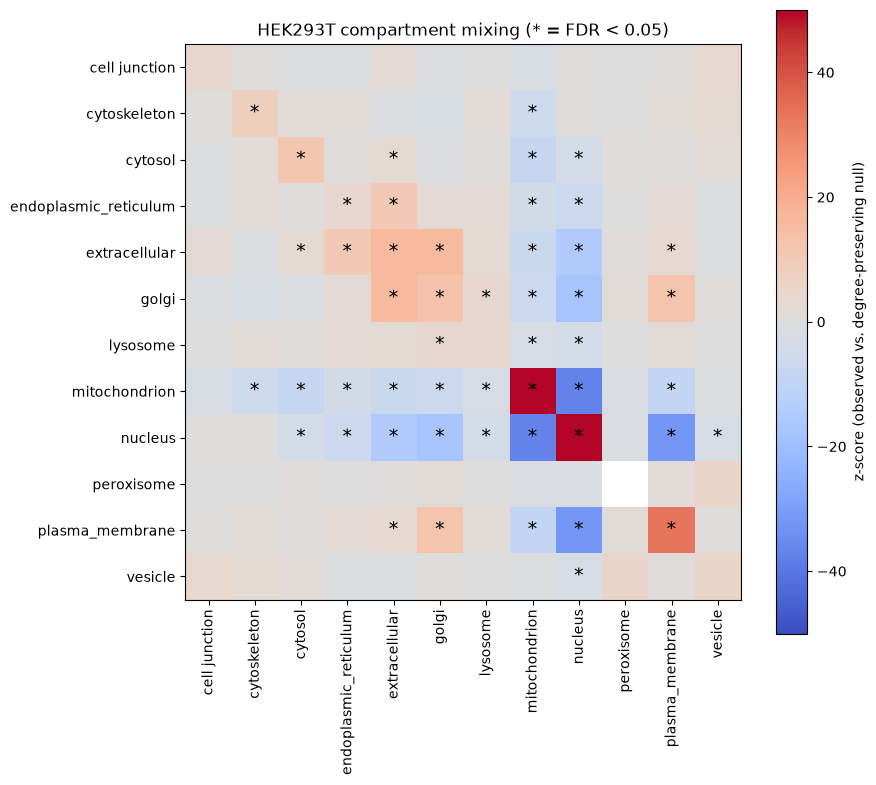

In [53]:
def plot_mixing_heatmap(scores: pd.DataFrame, compartments: list, title: str, ax=None):
    """Draw a compartment x compartment z-score heatmap, marking FDR-significant pairs with
    an asterisk.

    Parameters:
        scores (pd.DataFrame): per-pair scores as returned by score_mixing_matrix, with
            compartment_a, compartment_b, z_score, and significant columns.
        compartments (list): full list of compartment names to use as the heatmap's
            row/column order.
        title (str): title to display above the heatmap.
        ax (matplotlib.axes.Axes | None): axes to draw on. If None, a new figure and axes
            are created. Defaults to None.

    Returns:
        (matplotlib.axes.Axes): the axes the heatmap was drawn on.
    """
    z_matrix = pd.DataFrame(np.nan, index=compartments, columns=compartments)
    sig_matrix = pd.DataFrame(False, index=compartments, columns=compartments)
    for _, row in scores.iterrows():
        a, b, z, sig = row["compartment_a"], row["compartment_b"], row["z_score"], row["significant"]
        z_matrix.loc[a, b] = z_matrix.loc[b, a] = z
        sig_matrix.loc[a, b] = sig_matrix.loc[b, a] = sig

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 8))
    vmax = np.nanmax(np.abs(z_matrix.values))
    im = ax.imshow(z_matrix.values, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(compartments))); ax.set_xticklabels(compartments, rotation=90)
    ax.set_yticks(range(len(compartments))); ax.set_yticklabels(compartments)
    ax.set_title(title)

    for i, a in enumerate(compartments):
        for j, b in enumerate(compartments):
            if sig_matrix.loc[a, b]:
                ax.text(j, i, "*", ha="center", va="center", color="black", fontsize=14)

    plt.colorbar(im, ax=ax, label="z-score (observed vs. degree-preserving null)")
    return ax

fig, ax = plt.subplots(figsize=(9, 8))
plot_mixing_heatmap(scores_293t, compartments_list, "HEK293T compartment mixing (* = FDR < 0.05)", ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mixing_heatmap_293t.png", dpi=150)
plt.show()

## 2.6 Global summary: mutual information

The per-pair z-scores answer "is *this* pair enriched or depleted." This section adds one number
answering "how non-random is the *entire* mixing structure" -- useful as a single headline stat,
and directly reusable in Stage 4 (Jensen-Shannon divergence between HEK293T's and HCT116's overall
organization is built from the same object).

**This is where the counting convention changes.** We now build the properly normalized,
Newman-style symmetric joint distribution `e_ij`, where the full matrix sums to 1: diagonal cells
get `count / M`, and each off-diagonal pair of symmetric cells gets `count / (2M)` apiece (a
cross-compartment edge's probability mass is split evenly between its two symmetric matrix
entries; a same-compartment edge's mass all lands on one diagonal cell). This convention matters
here specifically because mutual information is defined over a normalized joint distribution.

Mutual information is then the KL divergence between that observed joint distribution and the
"independence" distribution built from its own marginals (`a_i` = total probability mass touching
compartment i) -- i.e., how much better the real joint distribution predicts an edge's endpoints
than assuming compartments interact independently, in proportion to their overall abundance.

In [54]:
def build_e_matrix(obs_counts: pd.Series, compartments: list) -> pd.DataFrame:
    """Build the normalized, symmetric joint probability distribution `e_ij` over
    compartment pairs (Newman-style mixing matrix), where the full matrix sums to 1.

    Parameters:
        obs_counts (pd.Series): observed edge counts indexed by canonical
            compartment-pair tuples, as returned by compute_mixing_counts.
        compartments (list): full list of compartment names to use as the matrix's
            row/column index.

    Returns:
        (pd.DataFrame): symmetric compartment x compartment DataFrame of joint edge
            probabilities; diagonal cells hold count / M, off-diagonal pairs split
            count / (2M) evenly across their two symmetric entries, where M is the total
            edge count.
    """
    M = obs_counts.sum()
    e = pd.DataFrame(0.0, index=compartments, columns=compartments)
    for (a, b), count in obs_counts.items():
        if a == b:
            e.loc[a, b] = count / M
        else:
            e.loc[a, b] = e.loc[b, a] = count / (2 * M)
    return e


def mutual_information_bits(e_matrix: pd.DataFrame) -> float:
    """Compute the mutual information (in bits) between a compartment-mixing joint
    distribution and the "independence" distribution implied by its own marginals -- a
    single summary statistic for how non-random the overall mixing structure is.

    Parameters:
        e_matrix (pd.DataFrame): normalized, symmetric joint probability distribution over
            compartment pairs, as returned by build_e_matrix.

    Returns:
        (float): mutual information in bits; 0 if compartment identity is uninformative
            about interaction partners, higher values indicate compartment identity
            predicts connection pattern more strongly.
    """
    a = e_matrix.sum(axis=1)  # marginals
    mi = 0.0
    for i in e_matrix.index:
        for j in e_matrix.columns:
            eij = e_matrix.loc[i, j]
            if eij > 0:
                mi += eij * np.log2(eij / (a[i] * a[j]))
    return mi


e_matrix_293t = build_e_matrix(obs_counts_293t, compartments_list)
mi_293t = mutual_information_bits(e_matrix_293t)
print(f"HEK293T compartment mixing mutual information: {mi_293t:.4f} bits")
print("(0 = compartment identity is uninformative about interaction partners; "
      "higher = compartment identity predicts connection pattern more strongly)")

HEK293T compartment mixing mutual information: 0.3910 bits
(0 = compartment identity is uninformative about interaction partners; higher = compartment identity predicts connection pattern more strongly)


## 2.7 Run the full pipeline on HCT116, and save everything

Same functions, same parameters, applied to `G_hct116_sub` -- this is the point of having built
each step as a reusable function rather than one-off script code. We are *not* yet comparing the
two cell lines statistically here (that's Stage 4) -- we're just producing matched, independently
computed outputs for each, ready to be compared.

HCT116: 5,775 edges used, 29 / 78 pairs significant at FDR < 0.05, MI = 0.5710 bits


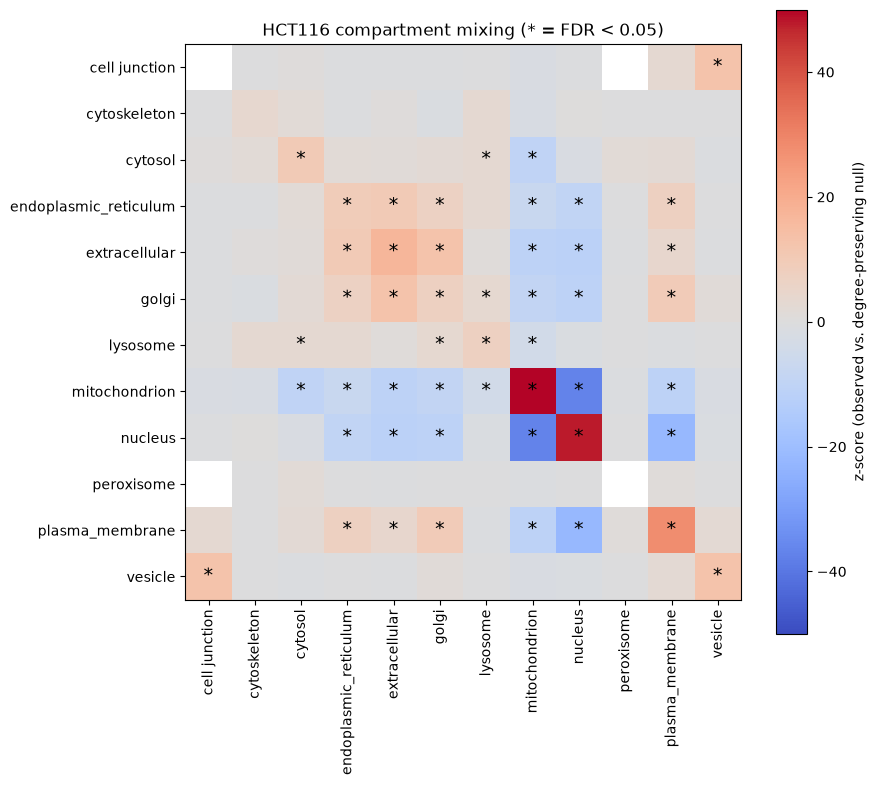

In [55]:
obs_counts_hct116 = compute_mixing_counts(G_hct116_sub)
obs_matrix_hct116 = mixing_counts_to_matrix(obs_counts_hct116, compartments_list)

null_dist_hct116 = build_null_distribution(G_hct116_sub, compartments_list, seed=RNG_SEED + 1)
scores_hct116 = score_mixing_matrix(obs_counts_hct116, null_dist_hct116)

e_matrix_hct116 = build_e_matrix(obs_counts_hct116, compartments_list)
mi_hct116 = mutual_information_bits(e_matrix_hct116)

print(f"HCT116: {obs_counts_hct116.sum():,} edges used, "
      f"{scores_hct116['significant'].sum()} / {len(scores_hct116)} pairs significant at FDR < 0.05, "
      f"MI = {mi_hct116:.4f} bits")

fig, ax = plt.subplots(figsize=(9, 8))
plot_mixing_heatmap(scores_hct116, compartments_list, "HCT116 compartment mixing (* = FDR < 0.05)", ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mixing_heatmap_hct116.png", dpi=150)
plt.show()

In [56]:
# Persist everything Stage 4 needs to compare the two cell lines, and everything Stage 3
# needs as background (compartments_list, e.g.).
obs_matrix_293t.to_csv(OUTPUT_DIR / "mixing_matrix_293t.csv")
obs_matrix_hct116.to_csv(OUTPUT_DIR / "mixing_matrix_hct116.csv")

scores_293t.to_csv(OUTPUT_DIR / "mixing_zscores_293t.csv", index=False)
scores_hct116.to_csv(OUTPUT_DIR / "mixing_zscores_hct116.csv", index=False)

with open(OUTPUT_DIR / "mixing_summary_293t.json", "w") as f:
    json.dump({"total_edges": int(obs_counts_293t.sum()), "mutual_information_bits": mi_293t,
               "n_significant_pairs": int(scores_293t["significant"].sum())}, f, indent=2)

with open(OUTPUT_DIR / "mixing_summary_hct116.json", "w") as f:
    json.dump({"total_edges": int(obs_counts_hct116.sum()), "mutual_information_bits": mi_hct116,
               "n_significant_pairs": int(scores_hct116["significant"].sum())}, f, indent=2)

print("Saved mixing matrices, z-score tables, and summary stats for both cell lines to ./data/stage2")

Saved mixing matrices, z-score tables, and summary stats for both cell lines to ./data/stage2


## Recap and what's next

For each cell line, `./data/stage2` now has: the raw observed mixing matrix, a full per-pair z-score /
FDR table, a heatmap PNG, and a one-number mutual-information summary.

**Worth inspecting by hand before Stage 3:**
- Which specific compartment pairs came out significantly *enriched* -- do any look like known
  biology (e.g. ER-mitochondria contact sites) as a sanity check?
- How many null-swap batches hit `NetworkXAlgorithmError` and got cut short in section 2.3 -- if
  this happened a lot, `null_std` may be slightly underestimated (less-thorough mixing than
  intended), which would make z-scores slightly liberal. Worth rerunning with a smaller
  `SWAPS_PER_SAMPLE_MULTIPLIER` batch size if so.

**Stage 3, next:** using the *same* induced subgraphs built here, plus the multi-compartment
proteins we set aside back in Stage 1, compute the participation coefficient for every protein and
identify candidate mediator/bridge proteins -- validating against known membrane-contact-site
tethers before trusting anything novel.

In [87]:
# scores_hct116.head()
for i, row in enumerate(scores_hct116.iterrows()):
    series = row[1]

    if (series["compartment_a"] == "peroxisome"
        and series["compartment_b"] == "peroxisome"):
        print(series)
        

compartment_a    peroxisome
compartment_b    peroxisome
observed                  0
null_mean               0.0
null_std                0.0
z_score                 NaN
p_empirical             1.0
q_value                 1.0
direction          depleted
significant           False
Name: 72, dtype: object
